# Beyond the Mainframe — first hour

**Not a solution.** This gets you past the cold start: what the data is, one
finding that is genuinely in it, and one technique worth carrying into your entry.

The technique here is **cost attribution and unit economics** — the two questions
a FinOps review always opens with, and the two that most teams skip straight past
on their way to a forecasting model.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from lib.loader import load
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

ch = load('c03-beyond-the-mainframe')
ch

<Challenge c03-beyond-the-mainframe (workload_cost_daily=419,750, chargeback_allocation=8,136, carbon_by_workload=419,750)>

In [2]:
# Read this before quoting any number from this notebook.
# Several tables across the programme look like observations and are not.
for c in ch.caveats():
    print('CAVEAT:', c)
else:
    print()
print('Tables:', {n: f'{len(d):,} rows' for n, d in ch.tables.items()})

CAVEAT: workload_cost_daily: Synthetic workload cost and utilisation by day, across a hybrid mainframe, on-premises and cloud estate.
CAVEAT: carbon_by_workload: Estimated carbon per workload per day. Grid intensity is SYNTHETIC — realistic in shape, not a measurement.

Tables: {'workload_cost_daily': '419,750 rows', 'chargeback_allocation': '8,136 rows', 'carbon_by_workload': '419,750 rows'}


## What the columns actually mean

Ask the manifest rather than guessing from dtypes. `dtypes` tells you a column is
a float; the contract tells you whether it is a percentage or a fraction.

In [3]:
ch.describe('workload_cost_daily')

,name,type,description
0,workload_id,string,"Stable workload identifier, WL-nnnnn."
1,usage_date,date,"Usage day, ISO-8601."
2,business_unit,string,Owning business unit. UNALLOCATED where owners...
3,service,string,"Billable service, e.g. CICS Transaction Server..."
4,platform,string,"One of mainframe, distributed, cloud."
5,environment,string,"One of production, staging, development, test."
6,region,string,Deployment region or on-premises site.
7,vcpu_hours,double,"Compute consumed that day, vCPU-hours (MIPS-eq..."
8,memory_gb_hours,double,"Memory consumed that day, GB-hours."
9,storage_gb,double,"Provisioned storage, GB. Flat per workload."


## Orient: grain, span, size

Before any analysis, confirm the grain is what the catalogue claims. A silent
duplicate at this stage inflates every number downstream and is nearly invisible
once you have aggregated.

In [4]:
cost = ch.tables['workload_cost_daily']

print('rows            ', f'{len(cost):,}')
print('workloads       ', f"{cost.workload_id.nunique():,}")
print('days            ', f"{cost.usage_date.nunique():,}")
print('expected rows   ', f'{cost.workload_id.nunique() * cost.usage_date.nunique():,}')
print('duplicated keys ', cost.duplicated(['workload_id','usage_date']).sum())
print()
print('date range      ', cost.usage_date.min(), '->', cost.usage_date.max())
print('total cost      ', f'GBP {cost.cost_gbp.sum():,.0f}')

rows             419,750
workloads        1,150
days             365
expected rows    419,750
duplicated keys  0

date range       2025-10-01 -> 2026-09-30
total cost       GBP 15,325,233


## Finding 1 — the spend nobody owns

The first question in any chargeback exercise is not *how much*, it is *whose*.
Untagged workloads are the classic gap: real money, no owner, and therefore nobody
with an incentive to reduce it.

In [5]:
total = cost.cost_gbp.sum()
untagged = cost[cost.business_unit == 'UNALLOCATED']

print(f'untagged workloads : {untagged.workload_id.nunique():,} of {cost.workload_id.nunique():,}')
print(f'untagged spend     : GBP {untagged.cost_gbp.sum():,.0f} ({untagged.cost_gbp.sum()/total:.1%} of total)')
print()
print('Top owners by spend:')
by_bu = cost.groupby('business_unit', as_index=False).cost_gbp.sum().sort_values('cost_gbp', ascending=False)
print(by_bu.head(8).to_string(index=False))

untagged workloads : 69 of 1,150
untagged spend     : GBP 1,159,419 (7.6% of total)

Top owners by spend:
      business_unit   cost_gbp
        UNALLOCATED 1159419.25
Customer Operations 1018088.12
          Insurance  863537.16
              Cards  806437.07
     Internal Audit  799010.14
               Risk  795644.79
         Compliance  723175.39
          Mortgages  705824.67


## Finding 2 — the same compute at very different prices

This is the technique: **normalise to a unit before comparing**. Total spend by
platform tells you where the money is. Cost *per vCPU-hour* tells you whether it is
well spent, and those two lead to opposite conclusions surprisingly often.

In [6]:
unit = (cost.groupby('platform')
            .agg(cost_gbp=('cost_gbp','sum'),
                 vcpu_hours=('vcpu_hours','sum'),
                 mean_util=('utilisation_pct','mean'))
            .assign(cost_per_vcpu_hr=lambda d: d.cost_gbp / d.vcpu_hours,
                    share_of_spend=lambda d: d.cost_gbp / d.cost_gbp.sum())
            .sort_values('cost_per_vcpu_hr', ascending=False))

unit.style.format({'cost_gbp':'GBP {:,.0f}', 'vcpu_hours':'{:,.0f}',
                   'mean_util':'{:.1f}%', 'cost_per_vcpu_hr':'GBP {:.4f}',
                   'share_of_spend':'{:.1%}'})

,cost_gbp,vcpu_hours,mean_util,cost_per_vcpu_hr,share_of_spend
platform,,,,,
mainframe,"GBP 13,150,116","26,661,616",69.5%,GBP 0.4932,85.8%
distributed,"GBP 1,112,106","12,261,818",36.3%,GBP 0.0907,7.3%
cloud,"GBP 1,063,011","15,593,038",21.2%,GBP 0.0682,6.9%


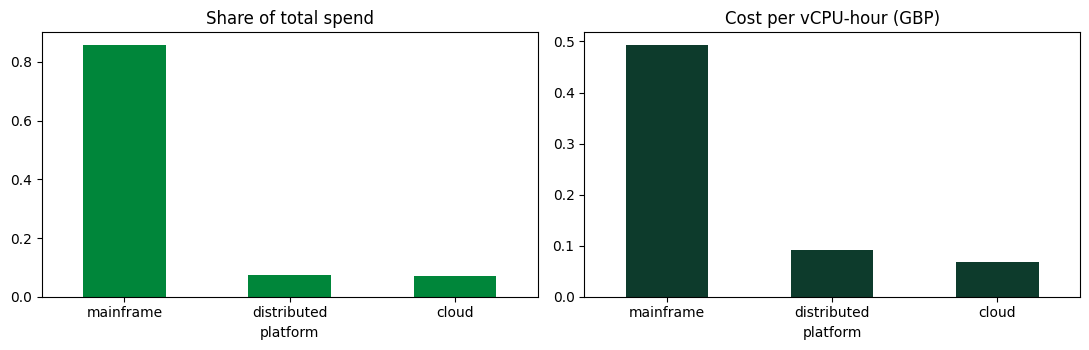

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
unit.share_of_spend.plot.bar(ax=ax[0], color='#00863a')
ax[0].set_title('Share of total spend'); ax[0].set_ylabel('')
unit.cost_per_vcpu_hr.plot.bar(ax=ax[1], color='#0d3b2c')
ax[1].set_title('Cost per vCPU-hour (GBP)'); ax[1].set_ylabel('')
for a in ax: a.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

### What to notice

Mainframe carries most of the spend **and** costs several times more per unit of
compute **and** runs at far higher utilisation than cloud.

That last part is the trap. High utilisation usually means efficiency, so the
obvious read — *migrate it* — is not obviously right: a platform running at 70% is
doing real work, while cloud at ~21% is mostly paying for idle. **A migration
argument that ignores utilisation is only half an argument.**

## Finding 3 — waste that utilisation makes visible

Near-idle workloads cost money and produce nothing. They are trivial to find once
you look, and easy to miss entirely if you only ever aggregate.

In [8]:
per_wl = (cost.groupby(['workload_id','platform','business_unit'], as_index=False)
              .agg(cost_gbp=('cost_gbp','sum'), mean_util=('utilisation_pct','mean')))
idle = per_wl[per_wl.mean_util < 5]

print(f'near-idle workloads : {len(idle):,}')
print(f'their annual cost   : GBP {idle.cost_gbp.sum():,.0f} ({idle.cost_gbp.sum()/total:.1%} of total)')
print()
print(idle.sort_values('cost_gbp', ascending=False).head(8).to_string(index=False))

near-idle workloads : 132
their annual cost   : GBP 1,431,083 (9.3% of total)

workload_id  platform       business_unit  cost_gbp  mean_util
   WL-00088 mainframe  Commercial Banking 119096.31   2.724658
   WL-00418 mainframe         Collections 103310.10   2.685479
   WL-00848 mainframe             Finance  65491.41   2.674521
   WL-00053 mainframe           Mortgages  56981.46   2.672877
   WL-00507 mainframe    Fraud Operations  54424.47   2.710411
   WL-00639 mainframe Customer Operations  53326.48   2.775616
   WL-00403 mainframe    Fraud Operations  52980.18   2.675890
   WL-00758 mainframe      Internal Audit  47908.46   2.620822


## Check your work: does chargeback reconcile?

`chargeback_allocation` is a roll-up of the cost table. If your analysis ever
disagrees with it, one of the two is wrong — and a chargeback table that does not
tie back to source is the single most common real-world FinOps defect.

In [9]:
cb = ch.tables['chargeback_allocation']
diff = abs(cost.cost_gbp.sum() - cb.allocated_cost_gbp.sum())
print(f'cost table    : GBP {cost.cost_gbp.sum():,.2f}')
print(f'chargeback    : GBP {cb.allocated_cost_gbp.sum():,.2f}')
print(f'difference    : GBP {diff:,.2f}')

# NULL, not zero, in a combination's first month. Zero would read as 'no change',
# which is a different and wrong statement.
print()
print('first-month rows with no prior to compare:', cb.variance_vs_prior_month_pct.isna().sum())

cost table    : GBP 15,325,232.68
chargeback    : GBP 15,325,232.68
difference    : GBP 0.00

first-month rows with no prior to compare: 678


## Where to go next

- Which business units would a 10% mainframe reduction actually affect?
- Does month-end batch explain the mainframe peaks, and what would smoothing be worth?
- `carbon_by_workload` joins on `workload_id` + `usage_date` — but read the caveat
  above first: **its grid intensity is synthetic**, so treat carbon as a method
  demonstration, never as a measured result.